<a href="https://colab.research.google.com/github/Yusra-Zafar/Simple-CNN-with-PyTorch/blob/main/CNN_with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FashionMNIST Image Classification using PyTorch CNN

## Code Flow

## 1. Setup and Imports

1. Dataloader objects
2. Training
3. Evaluation

In [ ]:
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [ ]:
# set random seed
torch.manual_seed(42)

## 2. Device Configuration

## Using GPU in PyTorch
1. Check device availability
2. Move the model to GPU
3. Modify the training loop by moving data to GPU
4. Modify the eval loop by moving data to GPU
5. Optimize GPU usage

    a. Use larger batch sizes (64, 128)

    b. Enable DataLoader pinning (pin_memory=True)

## device agnostic code

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using '{device}' device")

Using 'cuda' device


## 3. Data Loading and Preprocessing

## Importing FashionMNIST dataset from pytorch

In [ ]:
import torchvision
import torchvision.transforms as transforms
import pandas as pd


# Define a transformation to convert images to tensors
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Download and load the Fashion MNIST training dataset
train_dataset_full = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Extract features and labels from the full dataset
full_images = []
full_labels = []

for img, label in train_dataset_full:
    full_images.append(img.flatten().numpy())
    full_labels.append(label)

X = pd.DataFrame(full_images)
y = pd.Series(full_labels)


print(f"Loaded {len(X)} samples into X and y from Fashion MNIST.")

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 200kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.74MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.9MB/s]


Loaded 60000 samples into X and y from Fashion MNIST.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# scale dataset
X_train = X_train/255.0
X_test = X_test/255.0

## 4. Custom Dataset and DataLoader

In [ ]:
X_train

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
48572,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
38696,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000477,0.000015,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
13611,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
35213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000046,...,0.001984,0.001968,0.002261,0.002584,0.001984,0.000000,0.000000,0.0,0.0,0.0
31766,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000046,0.000877,0.001446,...,0.000000,0.000000,0.000000,0.000000,0.001845,0.001646,0.000431,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54343,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000015,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.003014,0.003183,0.001661,0.000000,0.0,0.0,0.0
38158,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
860,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000169,...,0.000031,0.000062,0.000000,0.001123,0.001492,0.001430,0.001107,0.0,0.0,0.0
15795,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001138,0.003199,0.000846,...,0.000400,0.000415,0.000461,0.000615,0.000138,0.000000,0.000000,0.0,0.0,0.0


In [ ]:
len(X_train)

48000

In [ ]:
len(y_test)

12000

In [ ]:
X_train.shape

(48000, 784)

In [ ]:
type(X_train)

pandas.core.frame.DataFrame

In [ ]:
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [ ]:
type(X_test),


(numpy.ndarray,)

In [ ]:
#create CustomDataset
class CustomDataset(Dataset):

    def __init__(self, features, labels): # constructor

        self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,28,28) # covert to single channel img, infer batches
        self.labels = torch.tensor(labels, dtype=torch.long)


    def __len__(self): # find length of the dataset

        return len(self.features)

    def __getitem__(self, index): # fetch a row of the dataset

        return self.features[index], self.labels[index]


Labels for classification tasks are usually integers because they represent discrete categories or classes (e.g., 0, 1, 2, ...). In PyTorch, torch.long (64-bit integer) is the standard data type for class labels, especially when using loss functions like CrossEntropyLoss that expect integer-based class indices. Floating-point numbers (float) are typically used for continuous numerical data, not for categorical labels.

In [ ]:
X_train.shape

(48000, 784)

In [ ]:
# create train_dataset object
train_dataset = CustomDataset(X_train, y_train)

In [ ]:
# create test_dataset object
test_dataset = CustomDataset(X_test, y_test)

In [ ]:
train_dataset[0]

(tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.000

In [ ]:
len(test_dataset)

12000

In [ ]:
len(train_dataset) + len(test_dataset)

60000

## 5. Model Definition (Convolutional Neural Network)

In [ ]:
# create train, test loader
train_loader = DataLoader(train_dataset, 32, True)
test_loader = DataLoader(test_dataset, 32, False)

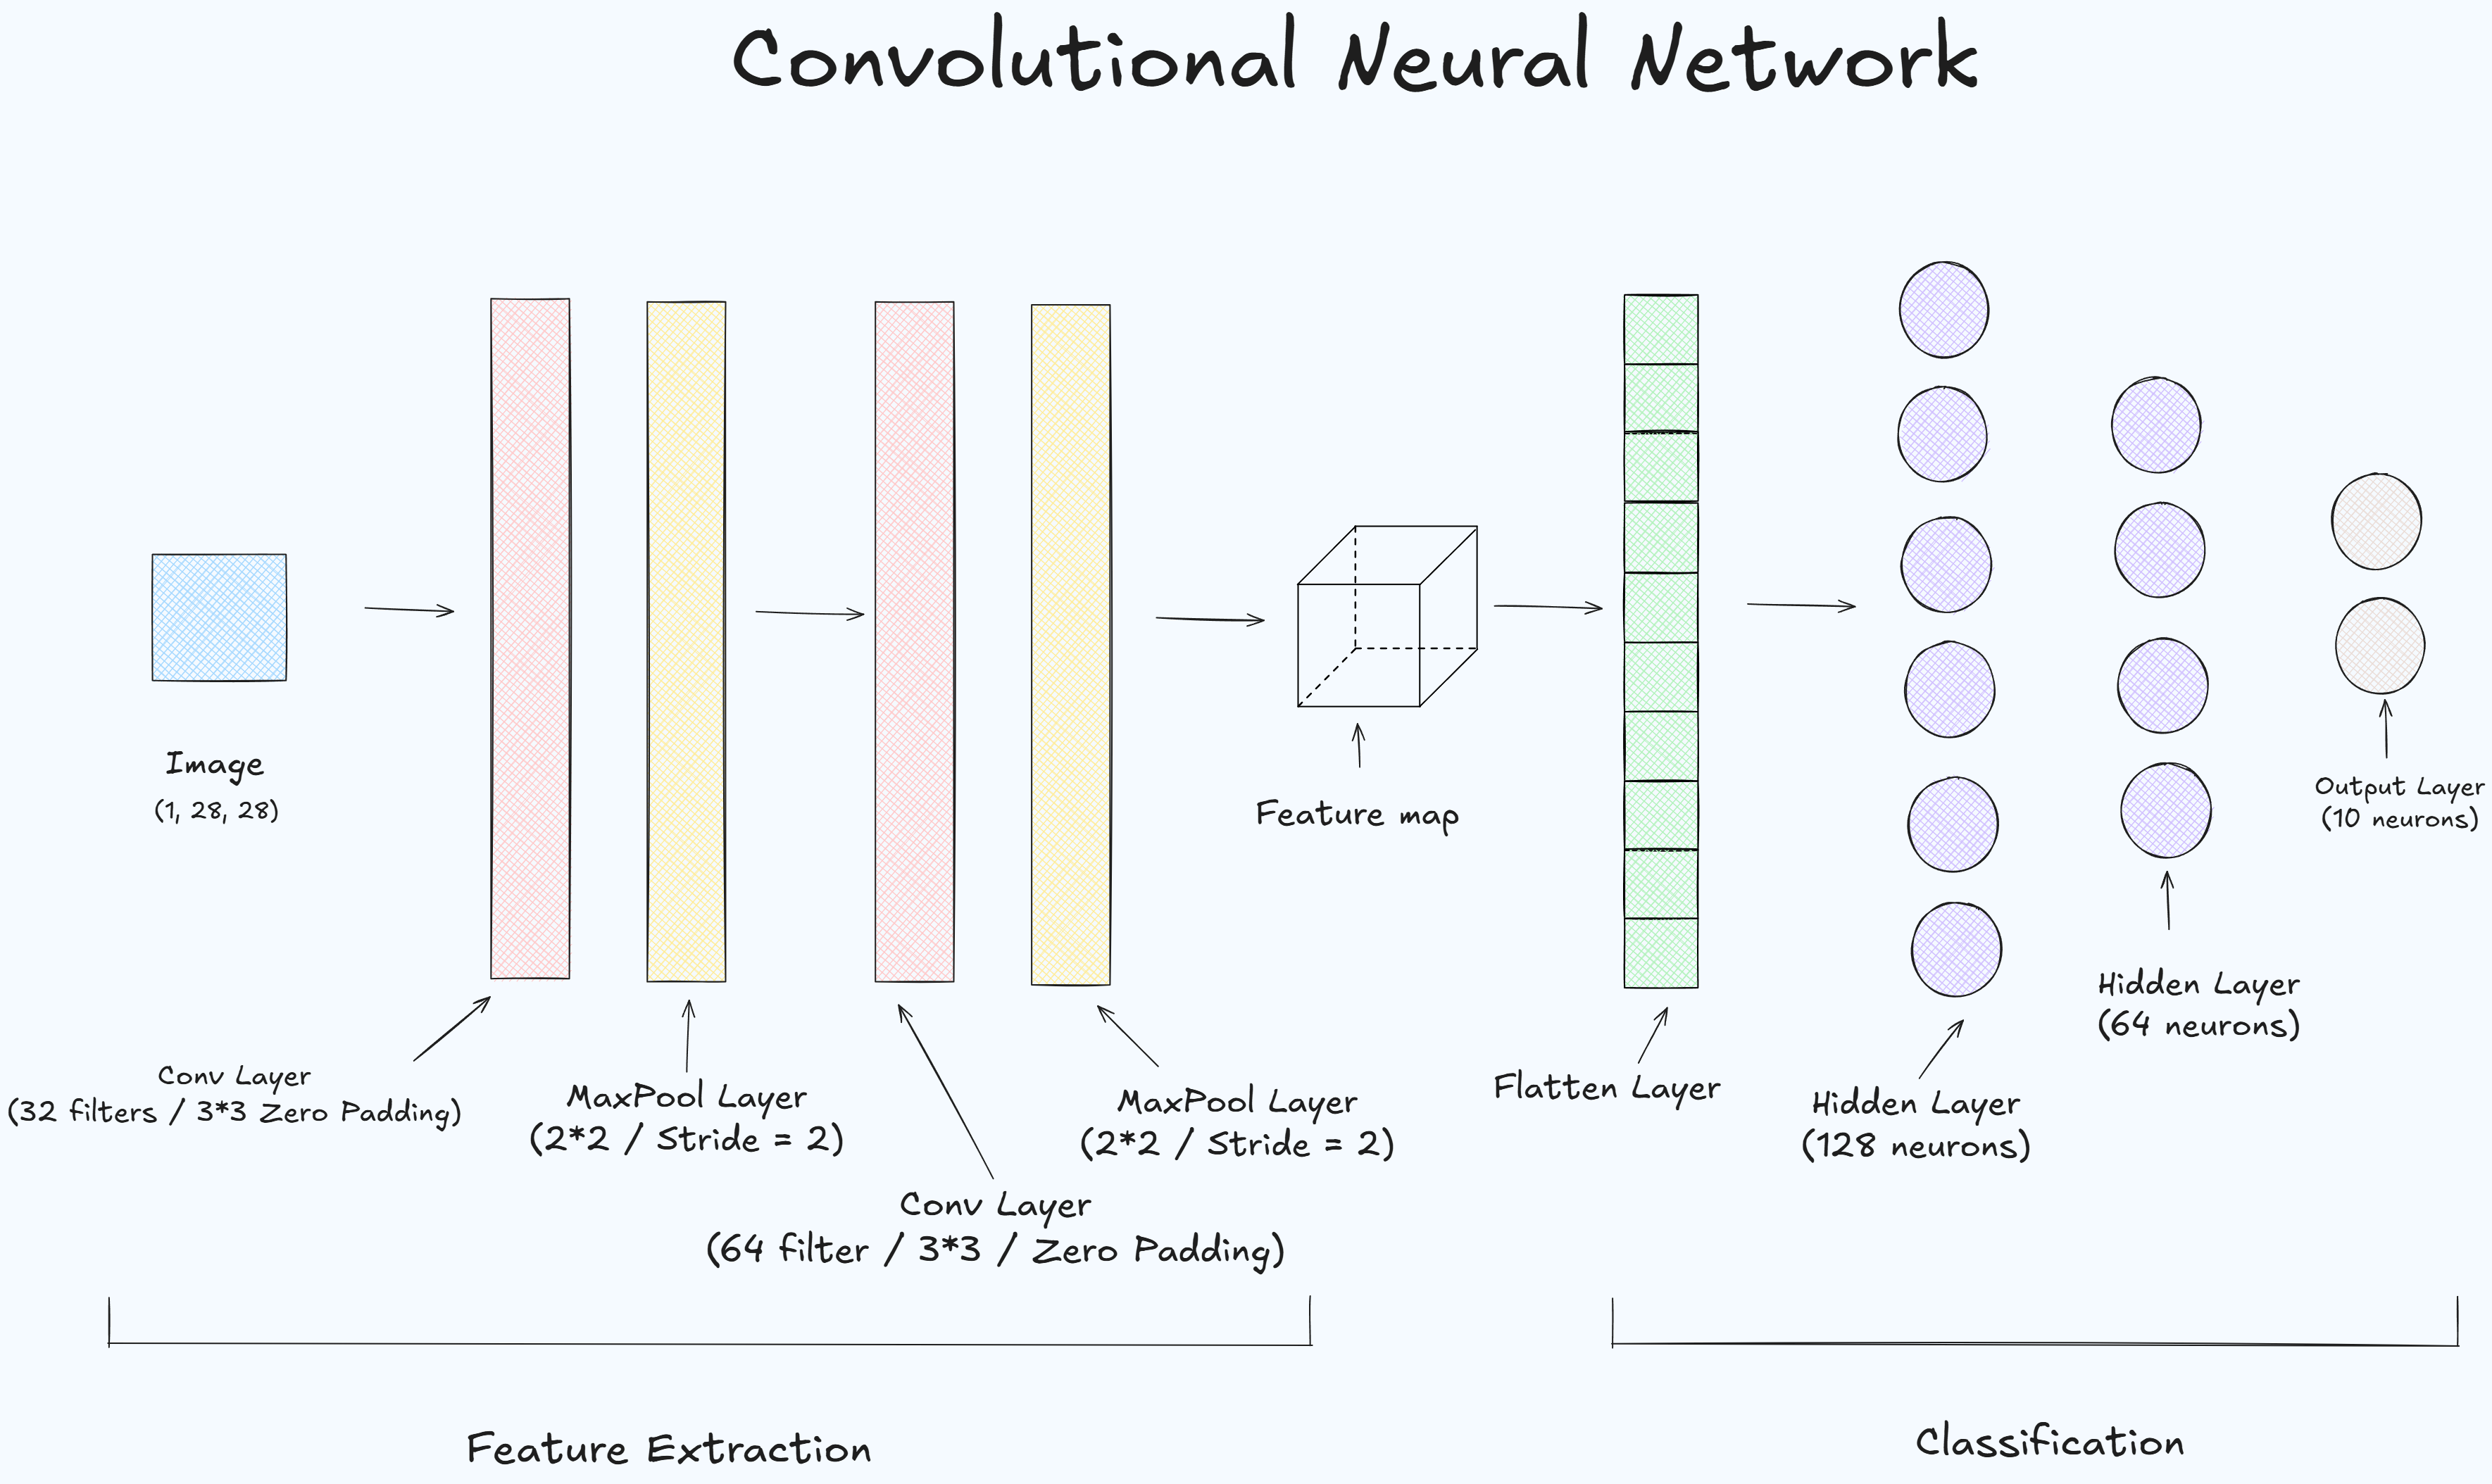

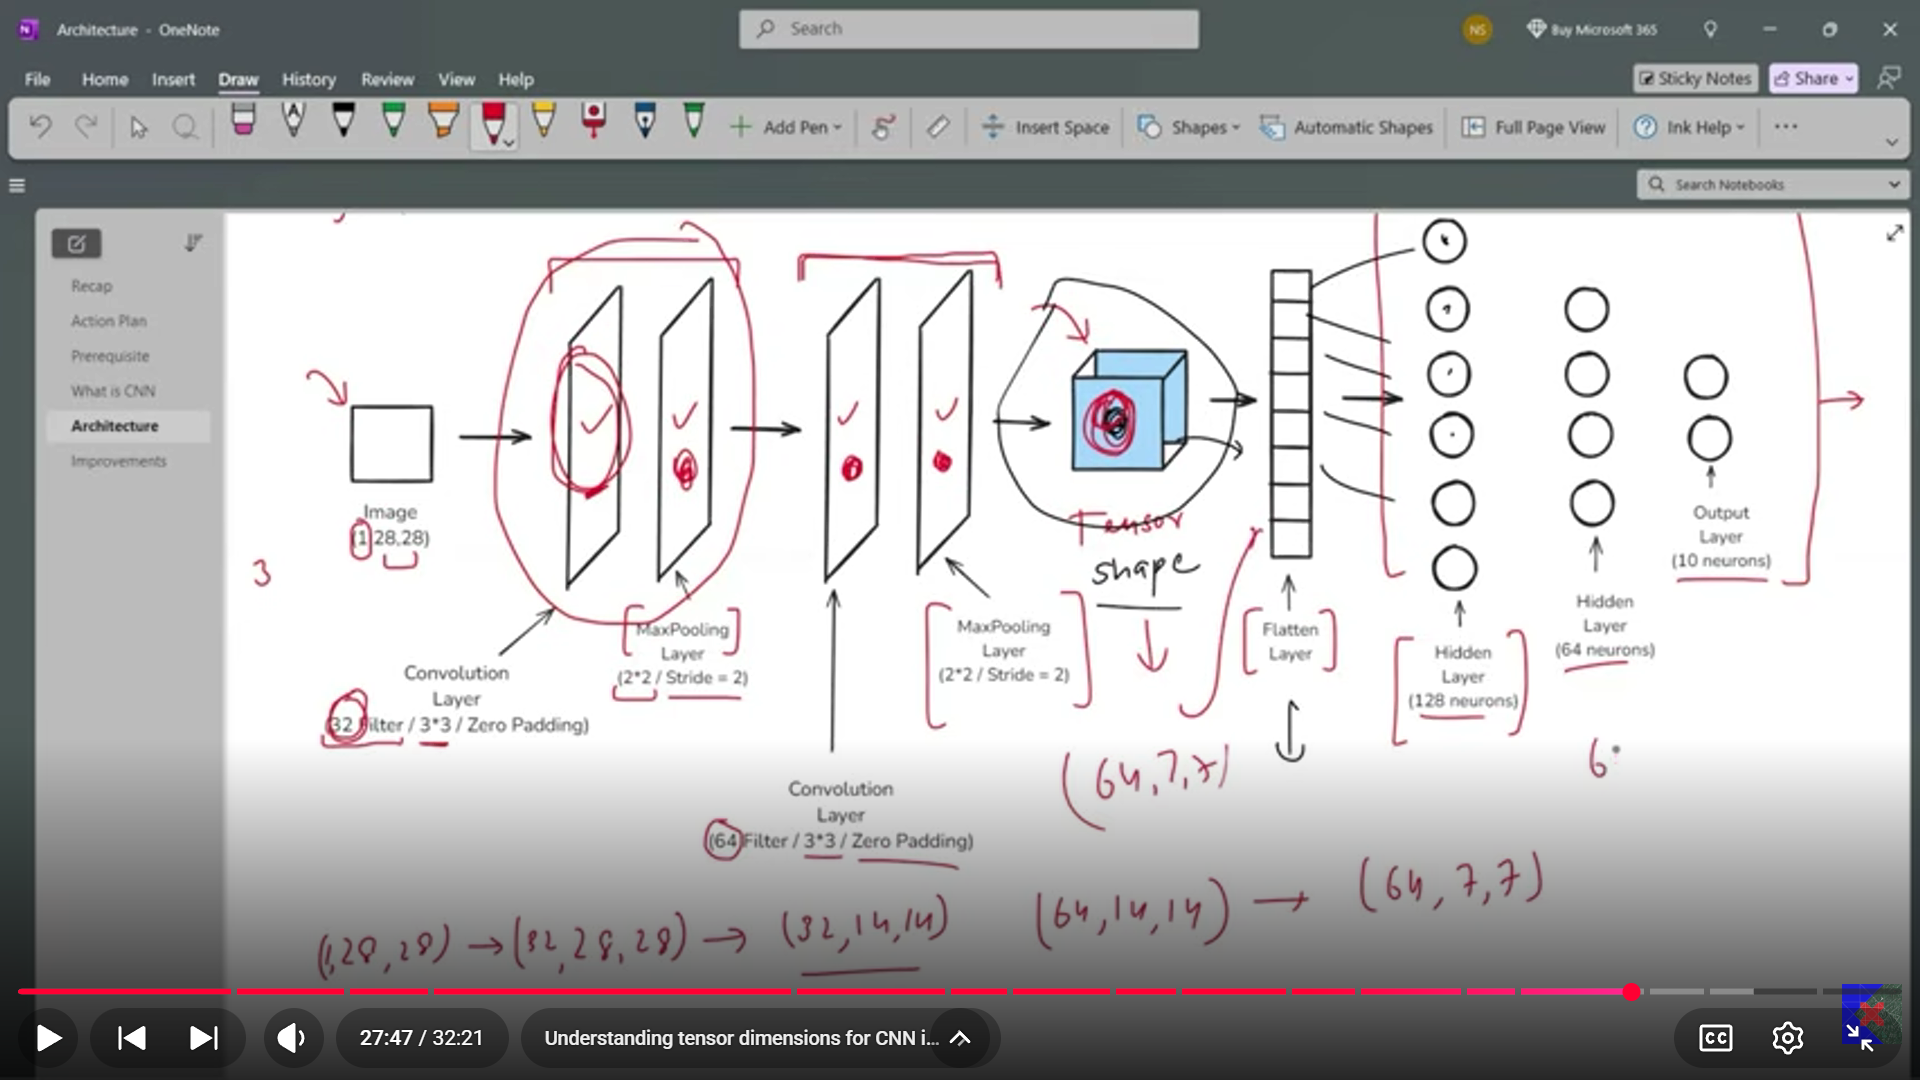

In [ ]:
from torch.nn.modules.pooling import MaxPool2d
# define NN class
class MyNN(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        # feature extraction
        self.features = nn.Sequential(
            nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # classification
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear((64*7*7), 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )


    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x

## 6. Model Training

In [ ]:
# set epochs and lr
epochs = 100
lr = 0.1

In [ ]:
# instantiate the modell
model = MyNN(1)
model.to(device) # move to gpu

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.SGD(model.parameters(), lr)

In [ ]:
# training loop

for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:
        # move data to gpu
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        # clear grads
        optimizer.zero_grad()

        # forward pass
        outputs = model(batch_features)

        # calculate loss
        loss = criterion(outputs, batch_labels)

        # backward pass
        loss.backward()

        # update params
        optimizer.step()

        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss / len(train_loader)
    print(f"Epoch: {epoch+1}, Loss: {avg_loss}")



Epoch: 1, Loss: 0.5455637071629366
Epoch: 2, Loss: 0.3424409543176492
Epoch: 3, Loss: 0.29424951883157097
Epoch: 4, Loss: 0.2654467253709833
Epoch: 5, Loss: 0.2464113281071186
Epoch: 6, Loss: 0.23233285619194308
Epoch: 7, Loss: 0.22100645038485528
Epoch: 8, Loss: 0.2098473896669845
Epoch: 9, Loss: 0.20168556708469987
Epoch: 10, Loss: 0.19248670151953895
Epoch: 11, Loss: 0.18621587360836567
Epoch: 12, Loss: 0.18134933296808353
Epoch: 13, Loss: 0.1776281061337019
Epoch: 14, Loss: 0.1719333057894061
Epoch: 15, Loss: 0.16426704925547045
Epoch: 16, Loss: 0.15891241803206504
Epoch: 17, Loss: 0.15573030017999312
Epoch: 18, Loss: 0.15443640589900315
Epoch: 19, Loss: 0.14856740925336878
Epoch: 20, Loss: 0.1457171940226108
Epoch: 21, Loss: 0.1412956697875634
Epoch: 22, Loss: 0.13967173645769557
Epoch: 23, Loss: 0.13383549454590926
Epoch: 24, Loss: 0.13407397920327882
Epoch: 25, Loss: 0.1289661855106242
Epoch: 26, Loss: 0.12514598385648182
Epoch: 27, Loss: 0.12422820900877317
Epoch: 28, Loss: 0.1

## 7. Model Evaluation

In [ ]:
# set model to eval model

model.eval()

MyNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.4, inplace=False)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

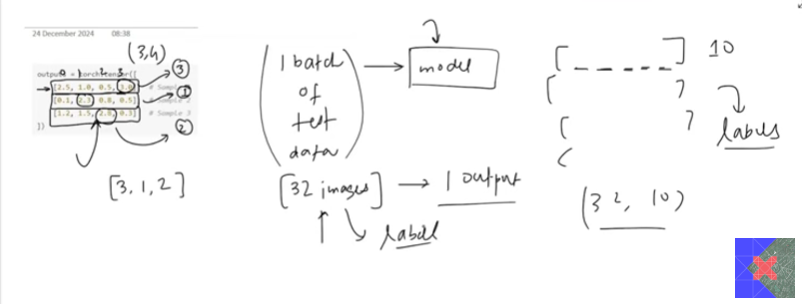

In [ ]:
# test evaluation
# Accuracy = Number of correct predictions/Total number of prediction

total_predictions = 0
correct_predictions = 0

with torch.no_grad():

    for batch_features, batch_labels in test_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        model_predictions = model(batch_features)
        _, predicted_labels_idx = torch.max(model_predictions, dim=1) #  the index of the maximum value along dim=1 (which represents the class probabilities) is the predicted class label.
        total_predictions += batch_features.shape[0] # adds 32 (batch size)
        correct_predictions += (predicted_labels_idx == batch_labels).sum().item()

    print(correct_predictions/total_predictions)

0.9245833333333333


In [ ]:
# train evaluation
# Accuracy = Number of correct predictions/Total number of prediction

total_predictions = 0
correct_predictions = 0

with torch.no_grad():

    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        model_predictions = model(batch_features)
        _, predicted_labels_idx = torch.max(model_predictions, dim=1) #  the index of the maximum value along dim=1 (which represents the class probabilities) is the predicted class label.
        total_predictions += batch_features.shape[0] # adds 32 (batch size)
        correct_predictions += (predicted_labels_idx == batch_labels).sum().item()

    print(correct_predictions/total_predictions)

0.9913958333333334
